In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import joblib

In [2]:
df = pd.read_csv("youtube_ad_revenue_dataset_featured.csv")

In [3]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate,watch_per_view,views_per_minute
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.155093,2.666789,3471.532423
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.098632,1.518393,421.980413
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.214519,5.678187,385.372360
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.142814,3.122834,852.481742
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.236121,1.584151,1490.237760


In [4]:
# Features & Setting Target

X = df.drop(columns=[
    "video_id",
    "date",
    "ad_revenue_usd"
])

y = df["ad_revenue_usd"]

In [5]:
# Setting Categorical & Numerical Column

categorical_cols = [
    "category",
    "device",
    "country"
]

numerical_cols = [
    "views",
    "likes",
    "comments",
    "watch_time_minutes",
    "video_length_minutes",
    "subscribers",
    "engagement_rate",
    "watch_per_view",
    "views_per_minute"
]

In [ ]:
# Preprocessing to convert the categories into numerical

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [7]:
# Test Train Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Defining Models

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [14]:
# Model Training & Evaluation

results = []

trained_pipelines = {}

for name, model in models.items():

    # Create pipeline
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train model
    pipe.fit(X_train, y_train)

    # Store trained pipeline
    trained_pipelines[name] = pipe

    # Predictions
    y_pred = pipe.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Save results
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# Create results dataframe
results_df = pd.DataFrame(results)

# Sort by highest R2 Score
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

# Display results
results_df

,Model,R2 Score,MAE,RMSE
2,Lasso Regression,0.952587,3.075400,13.478245
1,Ridge Regression,0.952580,3.109978,13.479258
0,Linear Regression,0.952573,3.114634,13.480137
4,Gradient Boosting,0.952223,3.616577,13.529776
3,Random Forest,0.949932,3.563501,13.850394


In [15]:
# Selecting best model

best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Lasso Regression


In [16]:
# Loading pipeline

best_pipe = trained_pipelines[best_model_name]

In [17]:
# Final Prediction

y_pred = best_pipe.predict(X_test)

In [18]:
# Final Metrics

print("R2 Score:", r2_score(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9525866501440718
MAE: 3.0753995463966386
RMSE: 13.478244540627275


In [19]:
best_model = best_pipe.named_steps["model"]

feature_names = (
    best_pipe.named_steps["preprocessor"]
    .get_feature_names_out()
)

In [ ]:
hasattr(best_model, "coef_")

NameError: name 'best_model' is not defined

In [ ]:
hasattr(model, "feature_importances_")

True

The model is Tree based

In [ ]:
# feature importance

if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    metric_col = "Importance"

elif hasattr(best_model, "coef_"):

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": best_model.coef_
    })

    importance_df["Importance"] = (
        importance_df["Coefficient"].abs()
    )

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    metric_col = "Importance"

importance_df.head(10)

,Feature,Coefficient,Importance
17,remainder__likes,1.707709e-02,1.707709e-02
18,remainder__comments,1.674502e-02,1.674502e-02
16,remainder__views,6.505740e-03,6.505740e-03
19,remainder__watch_time_minutes,4.714736e-03,4.714736e-03
24,remainder__views_per_minute,7.151871e-06,7.151871e-06
21,remainder__subscribers,9.415091e-08,9.415091e-08
2,cat__category_Gaming,-0.000000e+00,0.000000e+00
1,cat__category_Entertainment,0.000000e+00,0.000000e+00
0,cat__category_Education,0.000000e+00,0.000000e+00
8,cat__device_TV,-0.000000e+00,0.000000e+00


Feature Importance Interpretation:

1. Likes and comments were the strongest predictors of ad revenue.

2. Views and watch time also contributed significantly.

3. Lasso Regression reduced several less important categorical features to zero, effectively performing feature selection.

4. Engagement-related metrics had the strongest influence on monetization prediction.

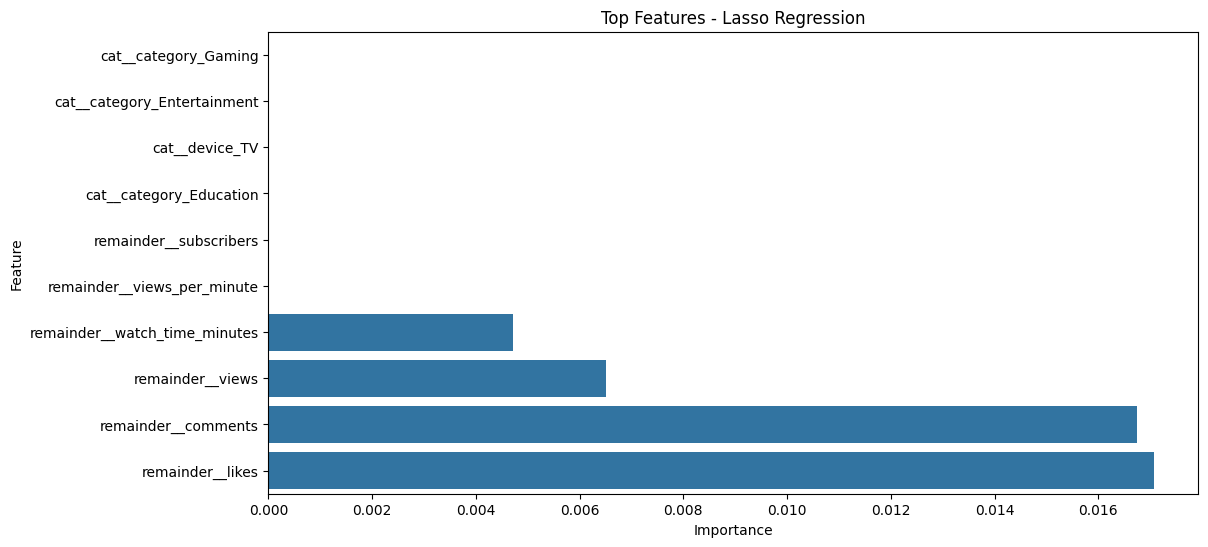

In [22]:
# Plotting top features

top_features = importance_df.head(10).sort_values(
    by=metric_col,
    ascending=True
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_features[metric_col],
    y=top_features["Feature"]
)

plt.title(f"Top Features - {best_model_name}")

plt.xlabel(metric_col)

plt.ylabel("Feature")

plt.show()

In [23]:
joblib.dump(best_pipe, "best_youtube_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.
